
# ***Analysis of operational performance and marketing effectiveness for a chain of chocolate shops***

Project objective

To conduct a comprehensive sales audit, identify key profit-driving regions, and assess how discounts and the loyalty programme impact the company’s financial performance.
Data description:

There are 5 relational tables available:
* **Sales**: transaction data (dates, quantity, revenue, profit, discounts)
* **Products**: product directory (brands, categories, cocoa content)
* **Stores**: information on points of sale (countries, cities, shop types)
* **Customers**: customer profiles (age, gender, loyalty status).
* **Calendar**: a calendar grid for analysing seasonality.

Technology stack:
`Python,
Pandas (data processing),
Matplotlib (visualisation),
Ticker (professional chart formatting).`

Key research questions:
* Geography: Which countries generate the majority of revenue?
* Seasonality: In which months do peaks and troughs in activity occur?
* Marketing: Are discounts paying off, and how do loyalty programme members behave?
* Demographics: Who is our main customer in terms of age?


Technical specifications

In [46]:
from itertools import groupby

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

calendar  = pd.read_csv("calendar.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")
stores = pd.read_csv("stores.csv")

dataframes=[calendar, customers, products, sales, stores]

In [47]:
print(stores.isnull().sum())
for i in dataframes:
    print(i.duplicated().sum())

store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64
0
0
0
0
0


**Geographical data:**

* Quantity of sales in every country
* Profit for every country
* Most popular store type

In [48]:
merged_df = pd.merge(sales, stores, on='store_id')

city_sales = merged_df.groupby('country')['quantity'].sum().reset_index()
ct_quant = city_sales.sort_values(by='quantity', ascending=False)
ct_quant.head()


,country,quantity
1,Canada,599270
4,UK,567747
5,USA,510229
2,France,510035
0,Australia,451891


In [49]:
df = sales.merge(stores, on='store_id')

result = df.groupby(['country', 'store_type'])['store_id'].nunique(). reset_index()
result.columns = ['country', 'store_type', 'count']

top = result.sort_values(['country', 'count'], ascending=[True, False]).drop_duplicates('country')

print(top.sort_values('count', ascending=False))

      country store_type  count
15         UK    Airport      9
12    Germany    Airport      8
6      Canada     Online      7
9      France       Mall      6
21        USA     Online      6
1   Australia       Mall      5


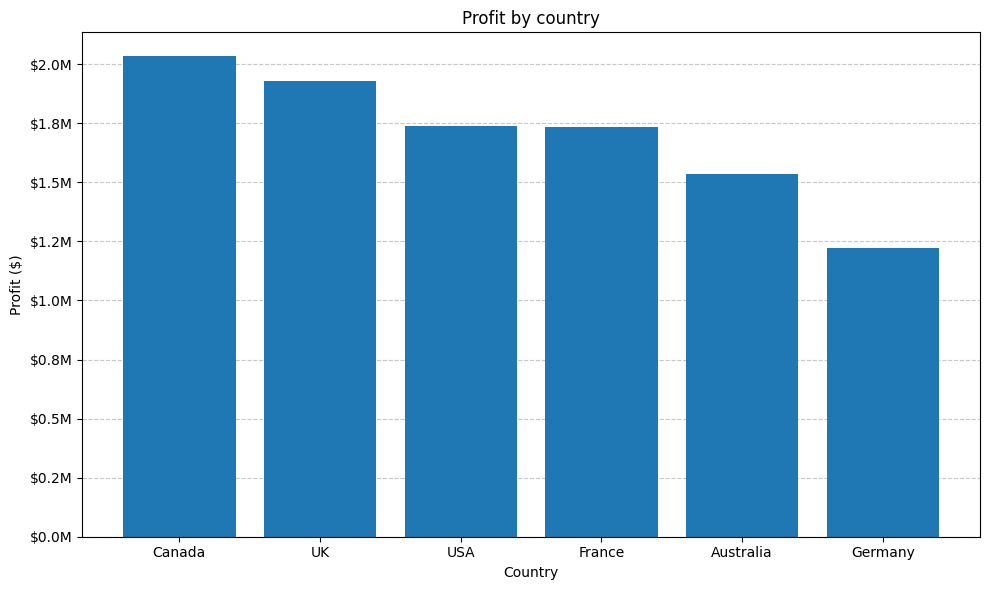

In [50]:
counrty_profit_plt = merged_df.groupby('country')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(counrty_profit_plt.index, counrty_profit_plt.values)

def millions_formatter(x, pos):
    return f'${x / 1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.title('Profit by country')
plt.xlabel('Country')
plt.ylabel('Profit ($)')

plt.tight_layout()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.show()

In [51]:
unique = stores['store_type'].drop_duplicates()
unique_sum = stores.groupby('store_type').value_counts()
print(unique_sum)
unique_sum = stores.groupby('store_type').size().sort_values(ascending=False)
print(unique_sum)

store_type  store_id  store_name          city       country  
Airport     S050      Chocolate Store 50  New York   Canada       1
            S030      Chocolate Store 30  New York   UK           1
            S040      Chocolate Store 40  Melbourne  Canada       1
            S041      Chocolate Store 41  London     Germany      1
            S043      Chocolate Store 43  London     Germany      1
                                                                 ..
Retail      S011      Chocolate Store 11  New York   USA          1
            S065      Chocolate Store 65  New York   Australia    1
            S069      Chocolate Store 69  London     France       1
            S052      Chocolate Store 52  Toronto    France       1
            S001      Chocolate Store 1   New York   Canada       1
Name: count, Length: 100, dtype: int64
store_type
Airport    30
Mall       26
Online     25
Retail     19
dtype: int64


Conclusion:
Canada and the United Kingdom offer the greatest potential; these should be the main focus.

Although they are not the most populous countries, they consume the most

**Seasonality Analysis: Monthly Sales Performance**

Quantity of sales in every month



In [52]:
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

df = sales.merge(calendar[['date', 'month']], left_on='order_date', right_on='date')

result = df.groupby('month').size().rename(index=month_names)

result.sort_values(ascending=False)

month
January      85375
May          85024
March        84968
July         84940
August       84933
October      84721
December     84665
September    82465
June         81793
November     81721
April        81612
February     77783
dtype: int64

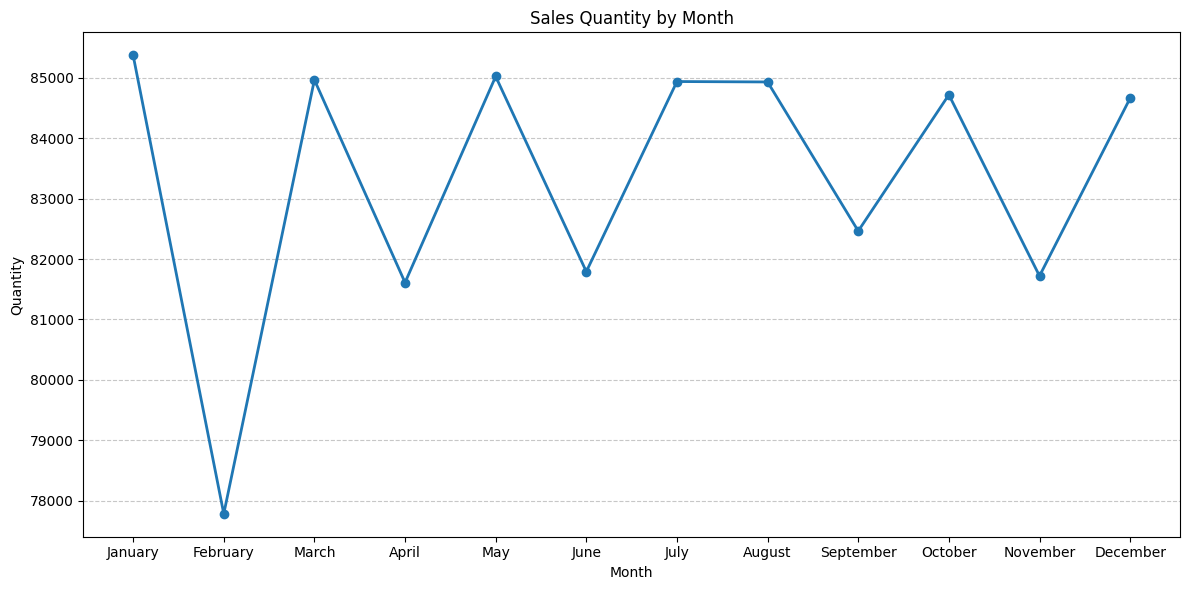

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(result.index, result.values, marker='o', linestyle='-', linewidth=2)

plt.title('Sales Quantity by Month')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

The shop’s range includes "200" unique items. The data has been checked for integrity: each ID corresponds to a unique product name

In [54]:
sales['year'] = pd.to_datetime(sales['order_date']).dt.year
sales['month'] = pd.to_datetime(sales['order_date']).dt.month
month_rev2 = sales.groupby(['year', 'month'])['revenue'].sum()
print(month_rev2)

year  month
2023  1        1095019.20
      2         968948.95
      3        1084656.09
      4        1038425.32
      5        1083418.79
      6        1046045.02
      7        1083223.13
      8        1086689.94
      9        1056935.75
      10       1071879.65
      11       1039418.12
      12       1080446.31
2024  1        1084751.00
      2        1010042.22
      3        1084560.82
      4        1043453.14
      5        1078643.18
      6        1038214.24
      7        1085923.34
      8        1082353.60
      9        1051414.03
      10       1075082.20
      11       1039335.10
      12       1077249.72
Name: revenue, dtype: float64


In [55]:
sales['days_in_month'] = pd.to_datetime(sales['order_date']).dt.days_in_month

month_rev3 = sales.groupby(['year', 'month']).agg(
    revenue=('revenue', 'sum'),
    days=('days_in_month', 'first')
).reset_index()

month_rev3['revenue_per_day'] = month_rev3['revenue'] / month_rev3['days']
print(month_rev3)

    year  month     revenue  days  revenue_per_day
0   2023      1  1095019.20    31     35323.200000
1   2023      2   968948.95    28     34605.319643
2   2023      3  1084656.09    31     34988.906129
3   2023      4  1038425.32    30     34614.177333
4   2023      5  1083418.79    31     34948.993226
5   2023      6  1046045.02    30     34868.167333
6   2023      7  1083223.13    31     34942.681613
7   2023      8  1086689.94    31     35054.514194
8   2023      9  1056935.75    30     35231.191667
9   2023     10  1071879.65    31     34576.762903
10  2023     11  1039418.12    30     34647.270667
11  2023     12  1080446.31    31     34853.106774
12  2024      1  1084751.00    31     34991.967742
13  2024      2  1010042.22    29     34829.042069
14  2024      3  1084560.82    31     34985.832903
15  2024      4  1043453.14    30     34781.771333
16  2024      5  1078643.18    31     34794.941290
17  2024      6  1038214.24    30     34607.141333
18  2024      7  1085923.34    

**Conclusion:**

* Peak Demand: The highest transaction volume is recorded in January (85,375 orders), which can be attributed to the holiday season and the redemption of gift vouchers.

* Annual Low: Sales reach their lowest point in February (77,783 orders), indicating a significant post-holiday slump in consumer activity.

* Steady Plateau: From March to August, sales remain consistently high (averaging above 84,000 orders), showing a stable period of sustained demand.

* Business Insight: To counter the February dip, the company should consider launching aggressive marketing campaigns or limited-edition "Valentine's Day" products to boost sales during this annual minimum

**Brand Performance**: Profitability and Popularity Audit

In [56]:
df_prod_sales = pd.merge(products,sales, on = 'product_id')
df_prod_sales.head()
df_brand_price = df_prod_sales.groupby('brand')['profit'].sum().sort_values(ascending=False).reset_index()
print(df_brand_price)

     brand      profit
0  Ferrero  1876268.09
1  Cadbury  1865555.75
2    Lindt  1770184.54
3     Mars  1660828.80
4   Godiva  1514949.08
5  Hershey  1407855.65


In [57]:
df_prod_sales.head()
brand_ord = df_prod_sales.groupby('brand')['order_id'].size().sort_values(ascending=False)
brand_ord_unique = df_prod_sales.groupby('brand')['order_id'].nunique().sort_values(ascending=False)
print(brand_ord_unique,brand_ord)

brand
Ferrero    183603
Cadbury    183230
Lindt      173163
Mars       163441
Godiva     148973
Hershey    137826
Name: order_id, dtype: int64 brand
Ferrero    183603
Cadbury    183230
Lindt      173163
Mars       163441
Godiva     148973
Hershey    137826
Name: order_id, dtype: int64


In [58]:
df_prod_sales.head()
unit_price_brand = df_prod_sales.groupby('brand')['unit_price'].mean().sort_values(ascending=False)
print(unit_price_brand)

brand
Lindt      9.015028
Cadbury    9.005827
Hershey    9.005711
Ferrero    8.998140
Godiva     8.998020
Mars       8.990919
Name: unit_price, dtype: float64


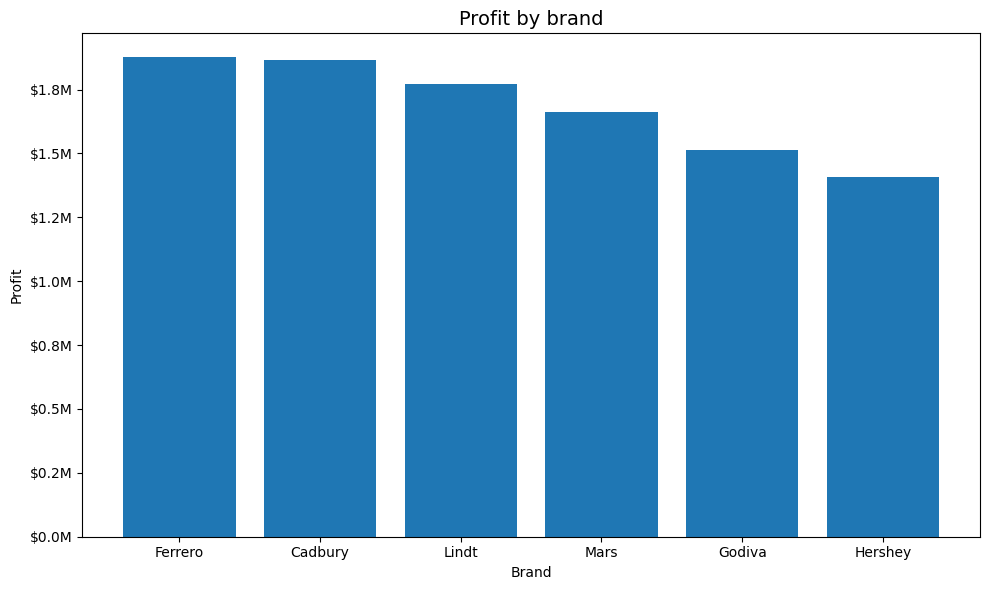

In [68]:
brand_profit = df_prod_sales.groupby('brand')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(brand_profit.index, brand_profit.values)
plt.title('Profit by brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Profit')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)
plt.tight_layout()
plt.show()

In [59]:
category_popularity = pd.merge(products, sales, on = 'product_id')
category_popularity.head()
category_mid = category_popularity.groupby('category')['profit'].sum().sort_values(ascending=False)
category_mid.head()
brand_popularity = category_popularity.groupby(['brand', 'category'])['profit'].sum().reset_index()

brand_popularity = brand_popularity.sort_values('profit', ascending=False)

brand_top_chocolate = brand_popularity.drop_duplicates('brand')
print(brand_top_chocolate)

      brand category     profit
4   Cadbury    White  659868.41
27     Mars  Praline  602549.45
5   Ferrero     Dark  506143.42
22    Lindt  Praline  503657.64
12   Godiva  Praline  402323.57
15  Hershey     Dark  350911.12


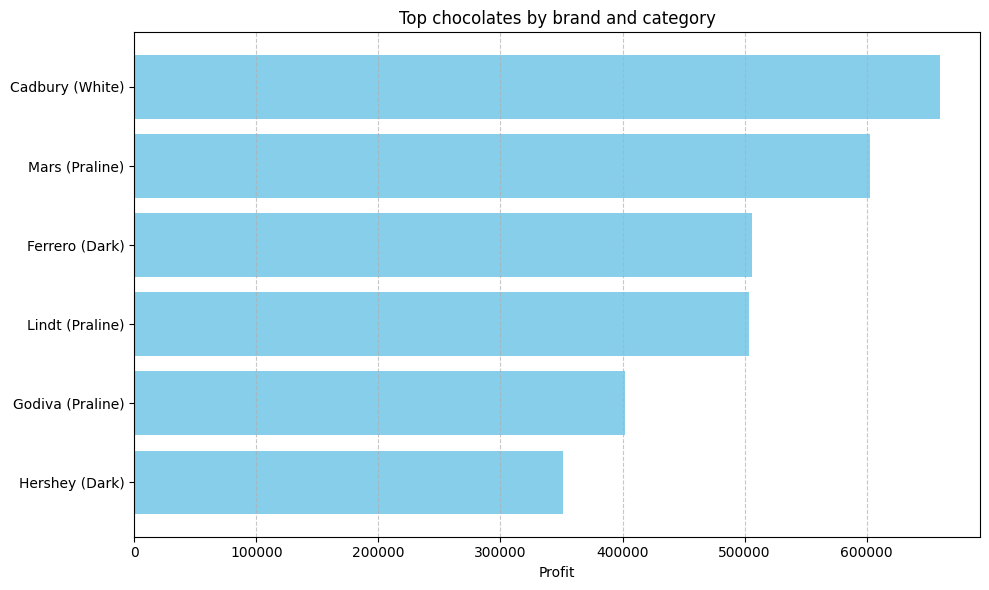

In [67]:
import matplotlib.pyplot as plt

labels = [f"{b} ({c})" for b, c in zip(brand_top_chocolate['brand'], brand_top_chocolate['category'])]
values = brand_top_chocolate['profit']

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color='skyblue')

plt.xlabel('Profit')
plt.title('Top chocolates by brand and category')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Market Leaders**: Ferrero and Cadbury are the primary profit drivers, generating $1.87M and $1.86M respectively.

**Customer Favorites**: Ferrero also leads in transaction volume with 183,603 orders, showing high brand loyalty.

**Premium Segment**: Lindt maintains the highest average unit price ($9.01), positioning it as the top-tier premium brand in the portfolio.

**Strategic Insight**: The Praline category (Mars/Cadbury) and Dark chocolate (Ferrero) are the most profitable niches; focus marketing efforts on these high-margin segments.

**Loyalty Program Impact**: Financial Performance and Customer Behavior

In [61]:

count = (customers['loyalty_member'] == 1).sum()
print(count)
count1 = (customers['loyalty_member'] == 0).sum()
print(count1)
a = customers['loyalty_member'].value_counts()
print(a)
customer_lol = pd.merge(customers, sales, on='customer_id')
customer_lol.head()

cus_lot = customer_lol.groupby('loyalty_member').agg(
    total_profit=('profit', 'sum'),
    avg_profit=('profit', 'mean'),
    orders=('order_id', 'count')
).reset_index()

print(cus_lot)

25104
24896
loyalty_member
1    25104
0    24896
Name: count, dtype: int64
   loyalty_member  total_profit  avg_profit  orders
0               0    5085560.24   10.209877  498102
1               1    5109004.39   10.179368  501898


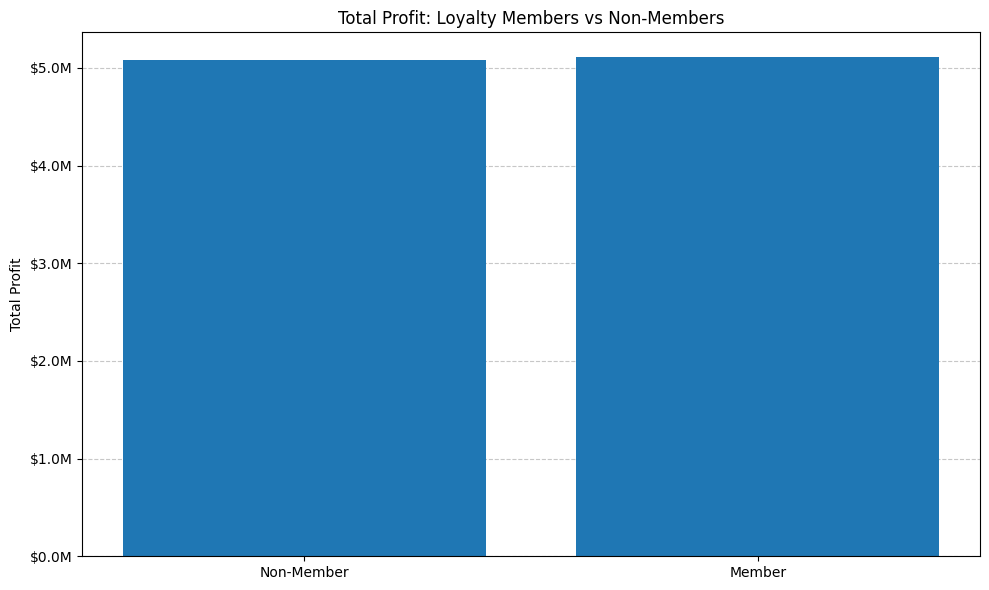

In [62]:

cus_lot['loyalty_status'] = cus_lot['loyalty_member'].map({1: 'Member', 0: 'Non-Member'})

plt.figure(figsize=(10, 6))
bars = plt.bar(cus_lot['loyalty_status'], cus_lot['total_profit'])


def millions(x, pos):
    return f'${x / 1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions))

plt.title('Total Profit: Loyalty Members vs Non-Members')
plt.ylabel('Total Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

**Equal Contribution**: Loyalty members and non-members contribute almost equally to total profit, generating $5.11M and $5.09M respectively.

**High Engagement**: The transaction count is nearly identical between groups (~500k orders each), suggesting the loyalty program has reached a significant portion of the active customer base.

**Profit Stability**: Average profit per order is consistent across both groups at approximately $10.20, indicating that loyalty rewards are not significantly eroding profit margins.

**Strategic Opportunity**: Since members do not yet spend significantly more than non-members, there is an opportunity to introduce exclusive high-value tiers to increase the "average check" for loyalists.

**Promotion Effectiveness**: Impact of Discounts on Sales Volume and Profitability

**Demographic Analysis**: Age Group

In [63]:
result_detailed = sales.groupby('discount')['profit'].agg(['mean', 'count'])
print(result_detailed)


               mean   count
discount                   
0.00      10.807276  625128
0.10       9.710761  124563
0.15       9.173563  125405
0.20       8.635604  124904


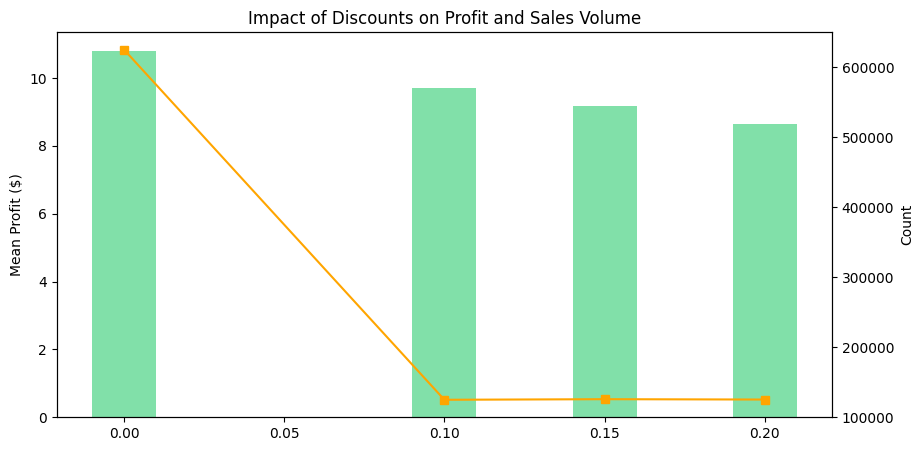

In [64]:
fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.bar(result_detailed.index, result_detailed['mean'], width=0.02, color='#2ecc71', alpha=0.6, label='Mean Profit')
ax1.set_ylabel('Mean Profit ($)')

ax2 = ax1.twinx()
ax2.plot(result_detailed.index, result_detailed['count'], color='orange', marker='s', label='Sales Count')
ax2.set_ylabel('Count')

plt.title('Impact of Discounts on Profit and Sales Volume')
plt.show()

In [65]:
bins = [0, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']

customer_sales_merge = pd.merge(customers, sales, on='customer_id')
customer_sales_merge['age_group'] = pd.cut(customer_sales_merge['age'], bins=bins, labels=labels)
age_profit_analysis = customer_sales_merge.groupby('age_group')['profit'].mean()

print("Average profit per purchase by age group:")
print(age_profit_analysis)

final_report = customer_sales_merge.groupby('age_group')['profit'].agg(['mean', 'count'])

print(final_report)

Average profit per purchase by age group:
age_group
18-30    10.188233
31-45    10.207382
46-60    10.188103
60+      10.193293
Name: profit, dtype: float64
                mean   count
age_group                   
18-30      10.188233  244401
31-45      10.207382  282107
46-60      10.188103  282487
60+        10.193293  191005


Profit Erosion: There is a direct inverse relationship between discount levels and profitability; at a 20% discount, the mean profit per item drops to $8.64 compared to $10.81 with no discount.

Volume Distribution: The majority of sales (625,128 orders) occur without any discount, while sales volume remains almost equally distributed across the 10%, 15%, and 20% discount tiers.

Strategic Insight: A 20% discount results in a 20% loss in profit margin; the business should consider 10% discounts as a more balanced tool for driving volume without severe profit loss.

Transaction Activity: The most active consumer segment is the 46–60 age group (282,487 transactions), followed closely by the 31–45 age group (282,107 transactions).

Profit Consistency: The average profit per purchase is remarkably consistent across all age groups at approximately $10.20, indicating uniform purchasing behavior regardless of age.

# **Executive Summary**

This analysis covers 1,000,000 transactions across 6 countries and 2 years (2023–2024).

**Key Findings:**

* Geography: Canada and UK are the top markets, generating $2,143,450 and $2,028,217 in profit respectively. Germany is the weakest market, heavily dependent on Airport stores.

*  Brands: Ferrero leads in total profit ($1.87M) driven by transaction volume (183,603 orders), not price — all brands have nearly identical average unit prices (~$9.00).

*  Categories: Praline is the most profitable category ($2,829,380), while Milk chocolate underperforms ($1,273,506).

*  Loyalty Program: The program shows no measurable impact — loyalty members and non-members generate equal profit per order (~$10.20). Recommend redesigning incentives.

*  Discounts: Every discount tier reduces profit margin. A 20% discount cuts profit from $10.81 to $8.64 per order. Recommend capping discounts at 10%.

*  Seasonality: No significant seasonal trends detected. Revenue per day is stable at ~$34,800 across all months in both years — business is stable but not growing.